# Perceptron — Wisconsin Breast Cancer Dataset

This notebook demonstrates the single-layer perceptron classifier on the Wisconsin Breast Cancer dataset. By the end you will be able to:

- Train a perceptron and evaluate its binary classification accuracy
- Plot a learning curve (accuracy vs. epoch) to understand convergence
- Observe how the learning rate affects final performance and weight magnitude
- Visualise the linear decision boundary via a 2D PCA projection

## Mathematical Intuition

The **perceptron** is the simplest linear classifier. It makes a prediction using:

$$\hat{y} = \text{sign}(\mathbf{w}^\top \mathbf{x} + b)$$

During training, whenever the prediction $\hat{y}$ disagrees with the true label $y$, the weights are updated by the **perceptron update rule**:

$$\mathbf{w} \leftarrow \mathbf{w} + \eta \cdot (y - \hat{y}) \cdot \mathbf{x}$$
$$b \leftarrow b + \eta \cdot (y - \hat{y})$$

where $\eta$ is the learning rate, $y \in \{-1, +1\}$ (or $\{0, 1\}$), and $\mathbf{x}$ is the input vector.

The **decision boundary** is the hyperplane $\mathbf{w}^\top \mathbf{x} + b = 0$. Points on one side are classified as positive, points on the other as negative.

**Convergence guarantee:** if the data is linearly separable, the perceptron converges in a finite number of steps. If the data is not linearly separable, the algorithm will cycle indefinitely — hence the importance of setting a maximum number of epochs.

## Dataset Overview

The **Wisconsin Breast Cancer** dataset contains features computed from digitised images of fine needle aspirate (FNA) biopsies.

| Feature group | Type | Description |
|---------------|------|-------------|
| 30 numeric features | Continuous | Mean, standard error, and worst value of 10 cell nucleus properties (radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension) |
| **target** | **Binary** | **0 = malignant, 1 = benign** |

- **Rows:** 569  
- **Features:** 30  
- **Target:** binary (malignant / benign)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from mlpackage import Perceptron, PCA, StandardScaler, train_test_split

sns.set_style("whitegrid")

data = load_breast_cancer()
X_raw, y_raw = data.data, data.target
feature_names = data.feature_names

print("Shape:", X_raw.shape)
print("Classes:", data.target_names)
print("Class counts:", np.bincount(y_raw))

Shape: (569, 30)
Classes: ['malignant' 'benign']
Class counts: [212 357]


## Exploratory Data Analysis

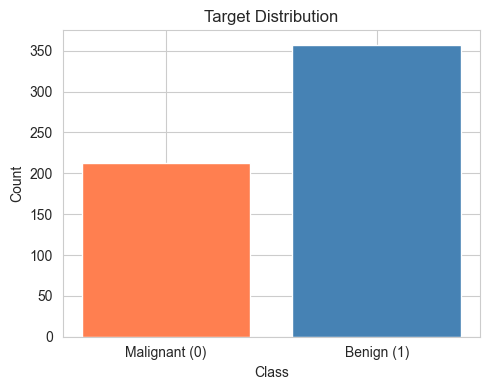

In [2]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Malignant (0)", "Benign (1)"], np.bincount(y_raw), color=["coral", "steelblue"])
ax.set_title("Target Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

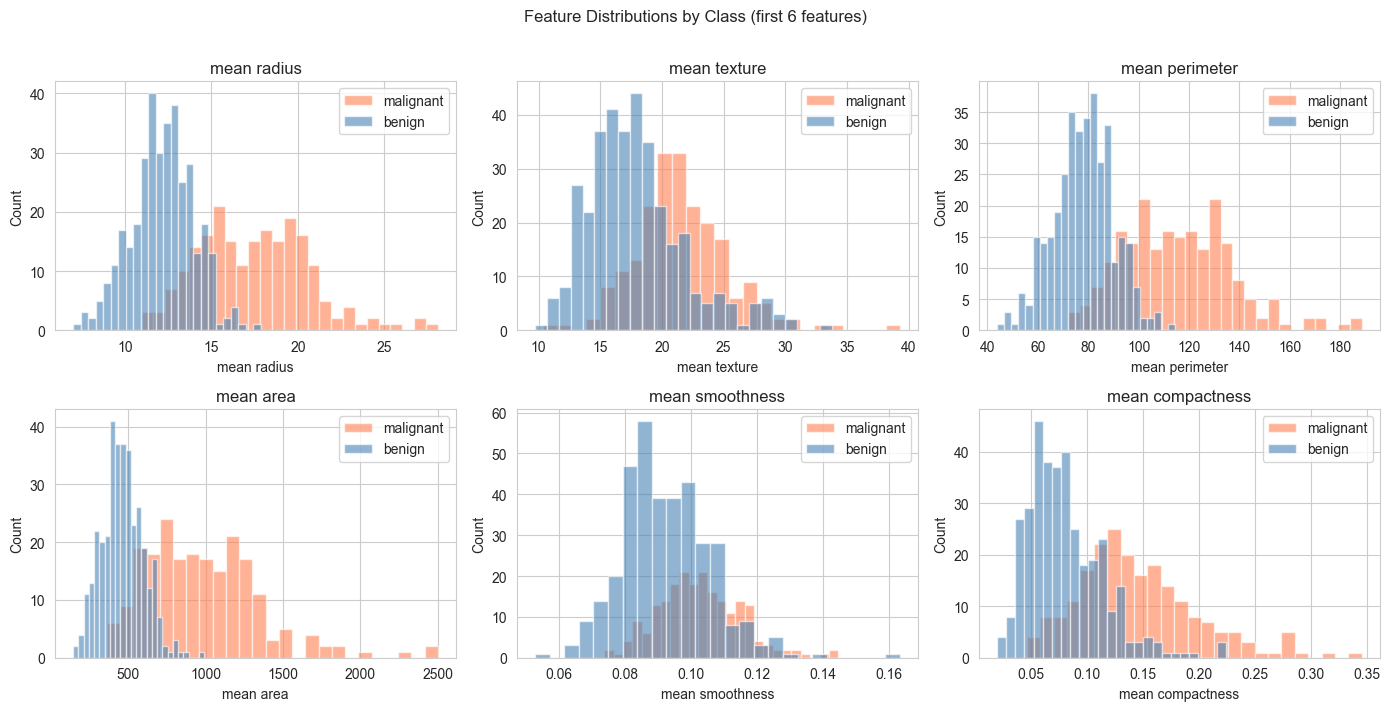

In [3]:
# First 6 features distribution
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, i in zip(axes.ravel(), range(6)):
    for cls, color in [(0, "coral"), (1, "steelblue")]:
        ax.hist(X_raw[y_raw == cls, i], bins=25, alpha=0.6, color=color,
                label=data.target_names[cls], edgecolor="white")
    ax.set_title(feature_names[i])
    ax.set_xlabel(feature_names[i])
    ax.set_ylabel("Count")
    ax.legend()
plt.suptitle("Feature Distributions by Class (first 6 features)", y=1.01)
plt.tight_layout()
plt.show()

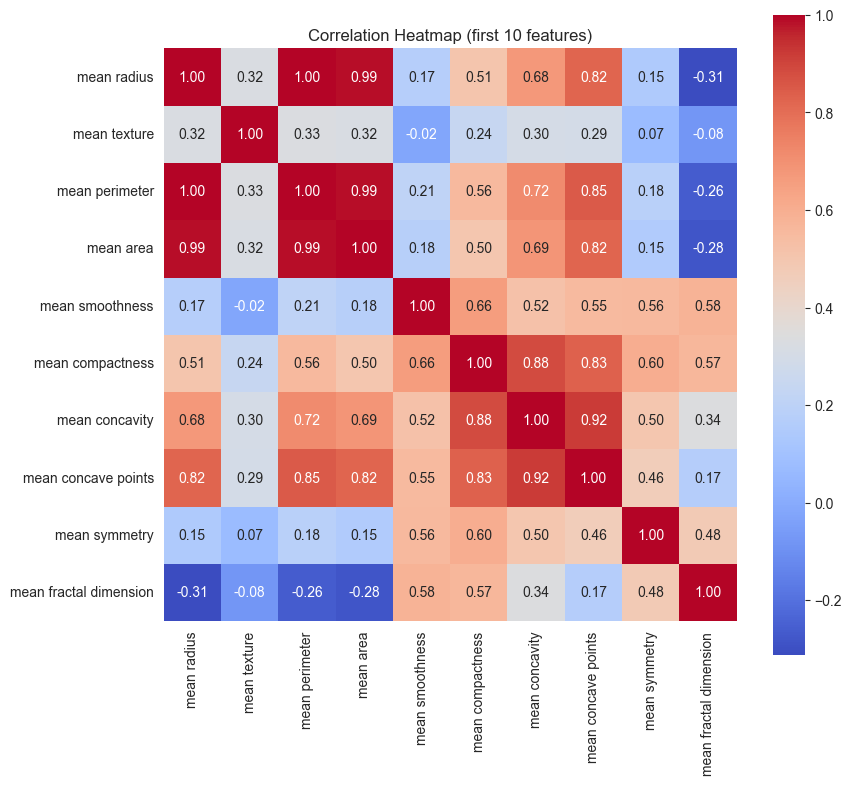

In [4]:
# Correlation heatmap on first 10 features for readability
df_corr = pd.DataFrame(X_raw[:, :10], columns=feature_names[:10])
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax, square=True)
ax.set_title("Correlation Heatmap (first 10 features)")
plt.tight_layout()
plt.show()

## Preprocessing

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size: {X_train_scaled.shape[0]}  |  Test size: {X_test_scaled.shape[0]}")

Train size: 455  |  Test size: 114


## Model Training

In [6]:
perceptron = Perceptron(learning_rate=1.0, n_epochs=1000)
perceptron.fit(X_train_scaled, y_train)

train_acc = perceptron.score(X_train_scaled, y_train)
test_acc  = perceptron.score(X_test_scaled,  y_test)
print(f"Train accuracy: {train_acc:.4f}  |  Test accuracy: {test_acc:.4f}")

Train accuracy: 1.0000  |  Test accuracy: 0.9386


## Evaluation

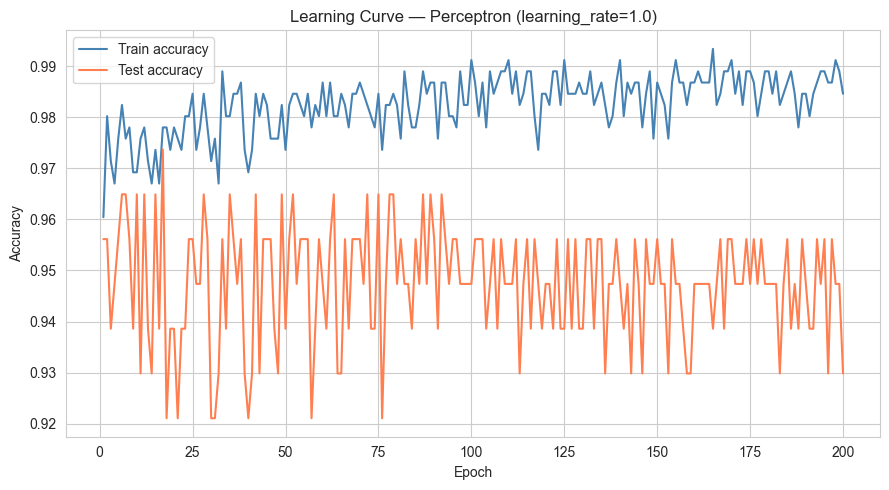

In [7]:
# Learning curve: accuracy vs epoch (refit with increasing n_epochs)
epoch_range = list(range(1, 201))
train_accs  = []
test_accs   = []

for ep in epoch_range:
    p = Perceptron(learning_rate=1.0, n_epochs=ep)
    p.fit(X_train_scaled, y_train)
    train_accs.append(p.score(X_train_scaled, y_train))
    test_accs.append(p.score(X_test_scaled,   y_test))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epoch_range, train_accs, label="Train accuracy", color="steelblue")
ax.plot(epoch_range, test_accs,  label="Test accuracy",  color="coral")
ax.set_title("Learning Curve — Perceptron (learning_rate=1.0)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

lr=0.001  Test acc: 0.9386  |  ||w||: 0.1834
lr=0.010  Test acc: 0.9386  |  ||w||: 1.8337
lr=0.100  Test acc: 0.9386  |  ||w||: 18.3372


lr=1.000  Test acc: 0.9386  |  ||w||: 183.3724


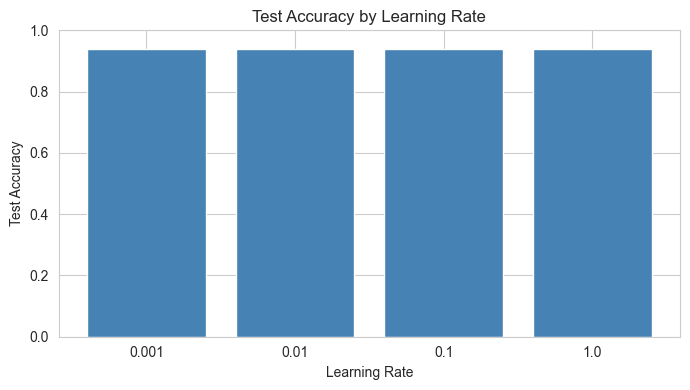

In [8]:
# Effect of learning rate
learning_rates = [0.001, 0.01, 0.1, 1.0]
lr_test_accs   = []
lr_weight_norms = []

for lr in learning_rates:
    p = Perceptron(learning_rate=lr, n_epochs=1000)
    p.fit(X_train_scaled, y_train)
    lr_test_accs.append(p.score(X_test_scaled, y_test))
    lr_weight_norms.append(np.linalg.norm(p.coef_))
    print(f"lr={lr:.3f}  Test acc: {lr_test_accs[-1]:.4f}  |  ||w||: {lr_weight_norms[-1]:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([str(lr) for lr in learning_rates], lr_test_accs, color="steelblue")
ax.set_title("Test Accuracy by Learning Rate")
ax.set_xlabel("Learning Rate")
ax.set_ylabel("Test Accuracy")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Visualisations

2D perceptron  Train acc: 0.9253  |  Test acc: 0.9123


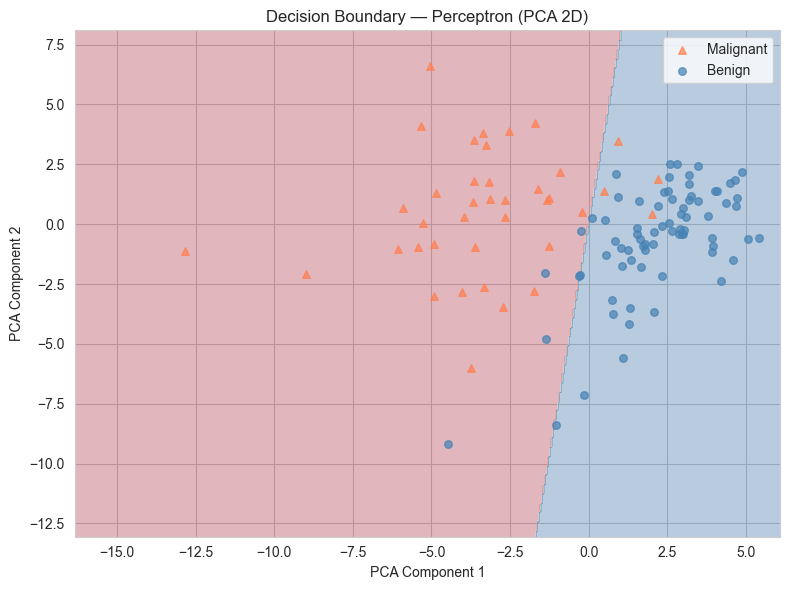

In [9]:
# Decision boundary via PCA 2D projection
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d  = pca.transform(X_test_scaled)

p2d = Perceptron(learning_rate=1.0, n_epochs=1000)
p2d.fit(X_train_2d, y_train)
print(f"2D perceptron  Train acc: {p2d.score(X_train_2d, y_train):.4f}  |  Test acc: {p2d.score(X_test_2d, y_test):.4f}")

h = 0.05
x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = p2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
for cls, color, marker, name in [(0, "coral", "^", "Malignant"), (1, "steelblue", "o", "Benign")]:
    mask = y_test == cls
    ax.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
               c=color, marker=marker, s=30, alpha=0.7, label=name)
ax.set_title("Decision Boundary — Perceptron (PCA 2D)")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.legend()
plt.tight_layout()
plt.show()

## Interpretation and Conclusions

- **The perceptron converges quickly on this dataset.** The learning curve shows accuracy stabilising well before 200 epochs, which is expected given that the breast cancer features are largely linearly separable after standardisation.

- **Learning rate has limited effect on final accuracy** at large epoch counts — all four rates converge to similar accuracy. The key difference is speed of convergence: very small learning rates (0.001) require more epochs to reach the plateau.

- **Weight vector magnitude grows with learning rate.** A larger $\eta$ applies larger weight corrections per misclassified sample, resulting in a higher $\|\mathbf{w}\|$. This does not affect the decision boundary direction, only its scale.

- **The PCA decision boundary is a straight line** — the perceptron always produces a linear classifier. The two classes separate well along the first principal component, confirming that most variance in the data is discriminative.

- **The perceptron's main limitation** is that it has no probabilistic output and no convergence guarantee on non-separable data. For probabilistic outputs, logistic regression is preferred.